Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Unzipping & Extracting

In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/raw_dataset.zip'
extract_path = '/content/driver_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/driver_dataset


In [4]:
for root, dirs, files in os.walk('/content/driver_dataset'):
    level = root.replace('/content/driver_dataset', '').count(os.sep)
    indent = '  ' * level
    print(indent + os.path.basename(root) + '/')

    for file in files[:10]:
        print(indent + '  ' + file)

    if level >= 2:
        dirs[:] = []

driver_dataset/
  paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-1-52.csv
  paved_sudden-acc_const-acc-at-60kmph_22-3-2023_20-35-48.csv
  paved_sudden-left-line-chg_const-acc-at-40kmph_22-3-2023_19-53-57.csv
  paved_safe-no-movement_zero-acc_22-3-2023_19-48-10.csv
  paved_sudden-right-turn_const-acc-at-20kmph_22-3-2023_20-12-12.csv
  paved_sudden-right-turn_const-acc-at-20kmph_22-3-2023_20-17-28.csv
  paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-50-49.csv
  paved_sudden-brake_const-acc-at-60kmph_22-3-2023_20-4-53.csv
  paved_sudden-brake_const-acc-at-20kmph_22-3-2023_19-18-52.csv
  paved_sudden-left-line-chg_const-acc-at-20kmph_20-2-2023_15-14-23.csv


In [5]:
import glob
import pandas as pd
import os

# Find acceleration/braking related CSV files
files = glob.glob('/content/driver_dataset/*.csv')

selected_files = [
    f for f in files
    if any(keyword in os.path.basename(f).lower()
           for keyword in [
               'sudden-acc',
               'sudden-brake',
               'safe_acc',
               'safe-acc',
               'safe-no-movement'
           ])
]

print("Number of selected files:", len(selected_files))

for f in selected_files:
    print(os.path.basename(f))


Number of selected files: 26
paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-1-52.csv
paved_sudden-acc_const-acc-at-60kmph_22-3-2023_20-35-48.csv
paved_safe-no-movement_zero-acc_22-3-2023_19-48-10.csv
paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-50-49.csv
paved_sudden-brake_const-acc-at-60kmph_22-3-2023_20-4-53.csv
paved_sudden-brake_const-acc-at-20kmph_22-3-2023_19-18-52.csv
paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv
paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-8-38.csv
paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-5-37.csv
paved_sudden-acc_const-acc-at-20kmph_22-3-2023_18-54-17.csv
paved_sudden-acc_const-acc-at-20kmph_22-3-2023_18-59-56.csv
paved_sudden-acc_const-acc-at-20kmph_20-2-2023_15-37-10.csv
paved_safe_acc_const-acc-at-40kmph_28-2-2023_15-48-43.csv
paved_sudden-brake_const-acc-at-20kmph_20-2-2023_14-53-15.csv
paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-10-50.csv
paved_sudden-brake_const-acc-at-20kmph_20-2-2023_15-1-7.csv
paved_sudden-brak

In [6]:
# Load each file and retain its source filename
parts = []

for f in selected_files:
    temp = pd.read_csv(f)
    temp['source_file'] = os.path.basename(f)
    parts.append(temp)

df = pd.concat(parts, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Unique source files:", df['source_file'].nunique())


Combined dataset shape: (16871, 15)
Unique source files: 26


Cleaning the dataset. The dataset already had no missing values and no duplicate rows.

In [7]:
print(df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

(16871, 15)


,sr_no,timestamp,road_type,harsh_event,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,event_class,source_file
0,1,22-3-2023 19:2:27:723888,paved,sudden-acc,1.145268,-1.298755,-4.378979,-0.003534,-0.108859,0.017846,-88.633163,84.961288,82.471954,0,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...
1,2,22-3-2023 19:2:28:63383,paved,sudden-acc,-0.416309,3.788345,-5.346581,-0.065320,0.021638,0.034624,-88.633163,84.961288,82.471954,0,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...
2,3,22-3-2023 19:2:28:66118,paved,sudden-acc,-0.713296,-1.490359,1.464958,-0.039754,0.037883,0.014118,-92.708259,87.388748,87.736129,0,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...
3,4,22-3-2023 19:2:28:74116,paved,sudden-acc,-1.690479,-1.011348,0.018345,-0.053336,0.086354,0.026102,-92.708259,87.388748,87.736129,0,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...
4,5,22-3-2023 19:2:28:114148,paved,sudden-acc,2.793067,-1.557421,3.342682,-0.040819,0.119910,-0.005856,-91.689491,89.816215,87.736129,0,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...



Columns:
['sr_no', 'timestamp', 'road_type', 'harsh_event', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'event_class', 'source_file']

Missing values:
sr_no          0
timestamp      0
road_type      0
harsh_event    0
acc_x          0
acc_y          0
acc_z          0
gyro_x         0
gyro_y         0
gyro_z         0
mag_x          0
mag_y          0
mag_z          0
event_class    0
source_file    0
dtype: int64

Duplicate rows:
0


In [8]:
print("Event class distribution:")
display(df['event_class'].value_counts())

print("\nHarsh event distribution:")
display(df['harsh_event'].value_counts())

Event class distribution:


,count
event_class,
0,13175
1,3696



Harsh event distribution:


,count
harsh_event,
sudden-acc,5109
sudden-brake,4698
sudden-acceleration,2997
uniform-accel,1648
cons-acc-40,1114
cons-acc-20,822
Safe-no-movement,483


In [9]:
display(df[['acc_x', 'acc_y', 'acc_z',
            'gyro_x', 'gyro_y', 'gyro_z',
            'mag_x', 'mag_y', 'mag_z']].describe())

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z
count,16871.000000,16871.000000,16871.000000,16871.000000,16871.000000,16871.000000,16871.000000,16871.000000,16871.000000
mean,-0.377608,-0.820022,-0.347660,-0.047508,0.002784,0.006418,-76.662422,28.996852,73.666568
std,2.369814,2.790229,4.071411,0.055072,0.071560,0.060451,35.331492,63.929714,23.214635
min,-38.742645,-24.775640,-45.384422,-0.580489,-0.732378,-0.775586,-113.764007,-93.999717,26.600414
25%,-1.443327,-2.351905,-2.481849,-0.078048,-0.033197,-0.006750,-103.657745,-42.270812,50.972076
50%,-0.395161,-0.797774,-0.415113,-0.047194,0.001948,0.002732,-95.022644,65.765373,83.106644
75%,0.691443,0.792045,1.737780,-0.016999,0.038293,0.014255,-49.936088,86.768967,91.703880
max,39.737358,40.202754,20.124187,0.611294,0.668024,0.480913,63.835827,114.940727,105.614685


In [10]:
pd.crosstab(df['harsh_event'], df['event_class'])

event_class,0,1
harsh_event,,
Safe-no-movement,483,0
cons-acc-20,822,0
cons-acc-40,1114,0
sudden-acc,3360,1749
sudden-acceleration,1886,1111
sudden-brake,3862,836
uniform-accel,1648,0


In [11]:
# Acceleration statistics

acc_cols = ['acc_x', 'acc_y', 'acc_z']

print("=== Acceleration Statistics ===")

acc_stats = df[acc_cols].describe().T

print(acc_stats)

=== Acceleration Statistics ===
         count      mean       std        min       25%       50%       75%  \
acc_x  16871.0 -0.377608  2.369814 -38.742645 -1.443327 -0.395161  0.691443   
acc_y  16871.0 -0.820022  2.790229 -24.775640 -2.351905 -0.797774  0.792045   
acc_z  16871.0 -0.347660  4.071411 -45.384422 -2.481849 -0.415113  1.737780   

             max  
acc_x  39.737358  
acc_y  40.202754  
acc_z  20.124187  


In [12]:
# Calculate total acceleration magnitude

df['acc_magnitude'] = np.sqrt(
    df['acc_x']**2 +
    df['acc_y']**2 +
    df['acc_z']**2
)

df[['acc_x', 'acc_y', 'acc_z', 'acc_magnitude']].describe()

,acc_x,acc_y,acc_z,acc_magnitude
count,16871.000000,16871.000000,16871.000000,16871.000000
mean,-0.377608,-0.820022,-0.347660,4.510217
std,2.369814,2.790229,4.071411,3.251226
min,-38.742645,-24.775640,-45.384422,0.115318
25%,-1.443327,-2.351905,-2.481849,2.498812
50%,-0.395161,-0.797774,-0.415113,3.770165
75%,0.691443,0.792045,1.737780,5.611368
max,39.737358,40.202754,20.124187,57.258531


In [13]:
# Acceleration statistics by driving event

event_stats = df.groupby('harsh_event')['acc_magnitude'].agg([
    'count',
    'mean',
    'std',
    'min',
    'max',
    'median'
]).sort_values('mean', ascending=False)

print(event_stats)

                     count      mean       std       min        max    median
harsh_event                                                                  
sudden-acc            5109  5.039499  3.555272  0.115318  57.258531  4.226035
sudden-brake          4698  4.782413  3.340025  0.252520  43.283592  4.048357
uniform-accel         1648  4.400601  3.092891  0.184825  28.014157  3.672059
sudden-acceleration   2997  4.232507  3.102630  0.302743  43.316413  3.587356
cons-acc-40           1114  3.847173  2.109172  0.273996  16.673083  3.444110
cons-acc-20            822  3.527300  2.202278  0.169203  21.822966  3.046245
Safe-no-movement       483  1.563313  0.818385  0.323363   8.551815  1.297141


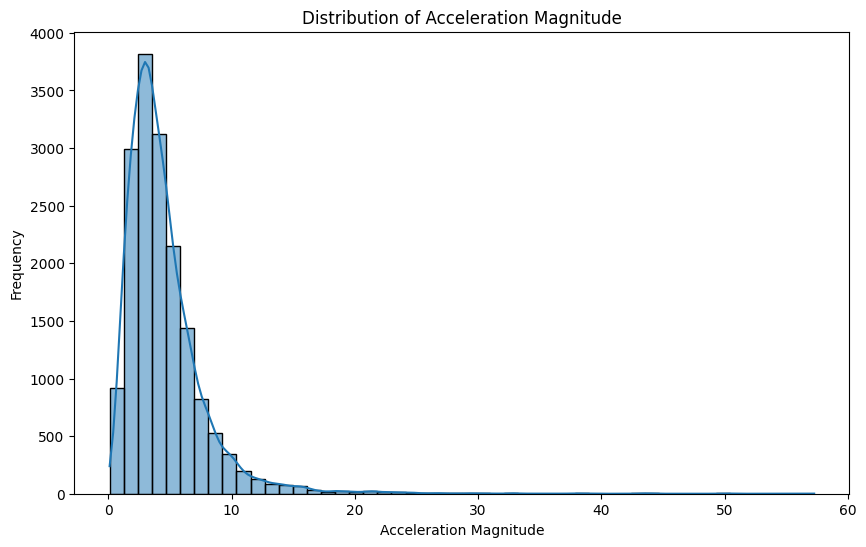

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df['acc_magnitude'], bins=50, kde=True)

plt.title('Distribution of Acceleration Magnitude')
plt.xlabel('Acceleration Magnitude')
plt.ylabel('Frequency')
plt.show()

1. Overall acceleration magnitude distribution

Most acceleration magnitudes are concentrated around 2–7.
The distribution is right-skewed, meaning most driving samples have moderate acceleration while a smaller number have very high acceleration.
Values extend up to around 57, which explains the long tail and the outliers.

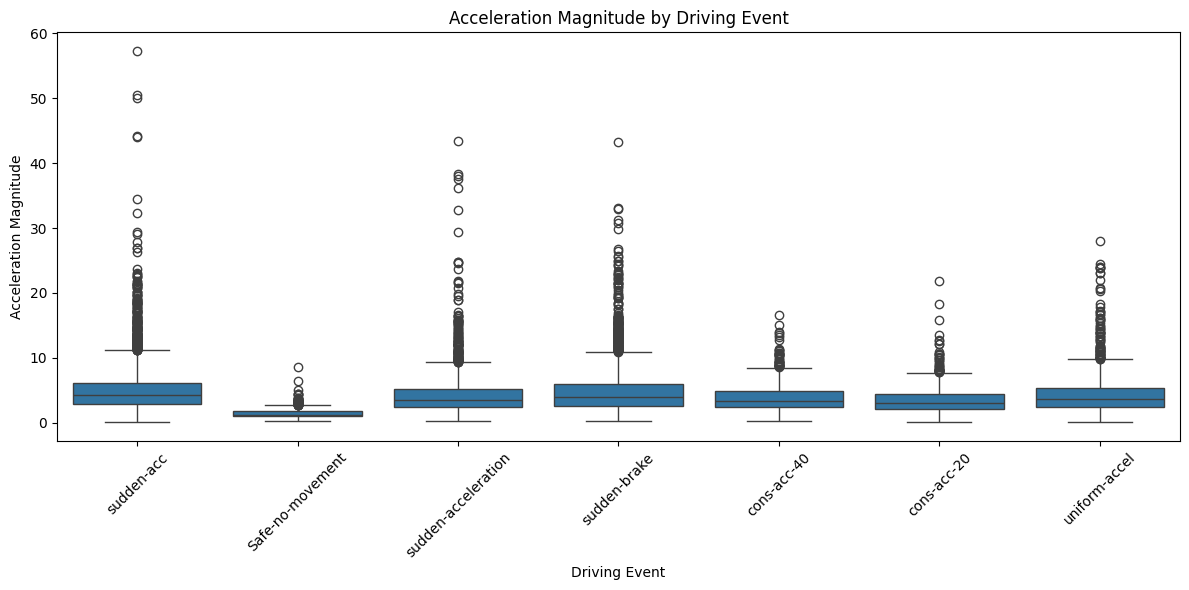

In [15]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='harsh_event',
    y='acc_magnitude'
)

plt.title('Acceleration Magnitude by Driving Event')
plt.xlabel('Driving Event')
plt.ylabel('Acceleration Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Boxplot by driving event

sudden-acc has one of the highest median acceleration magnitudes.
sudden-brake also has a relatively high median.
cons-acc-20 has the lowest median among the events.
There are many high-value outliers, especially for sudden-acc and sudden-brake.

In [16]:
# Calculate IQR

Q1 = df['acc_magnitude'].quantile(0.25)
Q3 = df['acc_magnitude'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 2.498811563609311
Q3: 5.611367687242492
IQR: 3.1125561236331807
Lower bound: -2.1700226218404604
Upper bound: 10.280201872692263


In [17]:
outliers = df[
    (df['acc_magnitude'] < lower_bound) |
    (df['acc_magnitude'] > upper_bound)
]

print("Number of potential outliers:", len(outliers))
print("Percentage of potential outliers:",
      len(outliers) / len(df) * 100)

Number of potential outliers: 764
Percentage of potential outliers: 4.528480825084465


In [18]:
outlier_event_counts = (
    outliers['harsh_event']
    .value_counts()
)

print(outlier_event_counts)

harsh_event
sudden-acc             312
sudden-brake           258
sudden-acceleration     97
uniform-accel           66
cons-acc-40             18
cons-acc-20             13
Name: count, dtype: int64


In [19]:
outlier_event_percentage = (
    outliers['harsh_event']
    .value_counts(normalize=True) * 100
)

print(outlier_event_percentage)

harsh_event
sudden-acc             40.837696
sudden-brake           33.769634
sudden-acceleration    12.696335
uniform-accel           8.638743
cons-acc-40             2.356021
cons-acc-20             1.701571
Name: proportion, dtype: float64


In [20]:
# Count potential high-acceleration outliers

outliers = df[df['acc_magnitude'] > upper_bound]

print("Potential high-acceleration outliers:", len(outliers))
print("Percentage of dataset:",
      round(len(outliers) / len(df) * 100, 2), "%")

Potential high-acceleration outliers: 764
Percentage of dataset: 4.53 %


In [21]:
# Calculate overall acceleration magnitude
df['acc_magnitude'] = np.sqrt(
    df['acc_x']**2 +
    df['acc_y']**2 +
    df['acc_z']**2
)

df[['acc_x', 'acc_y', 'acc_z', 'acc_magnitude']].head()

,acc_x,acc_y,acc_z,acc_magnitude
0,1.145268,-1.298755,-4.378979,4.708913
1,-0.416309,3.788345,-5.346581,6.565881
2,-0.713296,-1.490359,1.464958,2.208181
3,-1.690479,-1.011348,0.018345,1.969995
4,2.793067,-1.557421,3.342682,4.626047


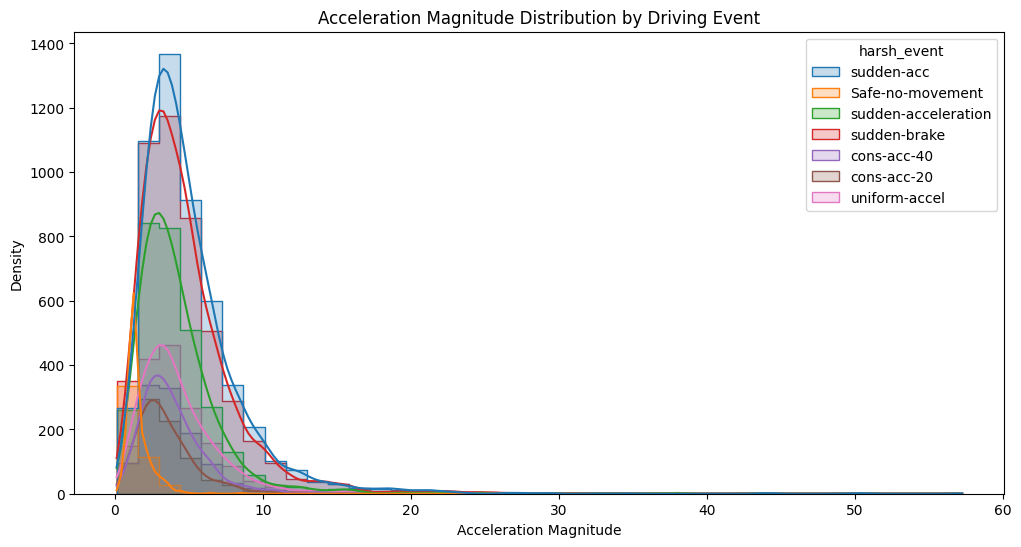

In [22]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='acc_magnitude',
    hue='harsh_event',
    bins=40,
    kde=True,
    element='step',
    common_norm=False
)

plt.title('Acceleration Magnitude Distribution by Driving Event')
plt.xlabel('Acceleration Magnitude')
plt.ylabel('Density')
plt.show()

The data suggests that sudden acceleration and sudden braking are associated with stronger acceleration-magnitude changes than controlled acceleration events.

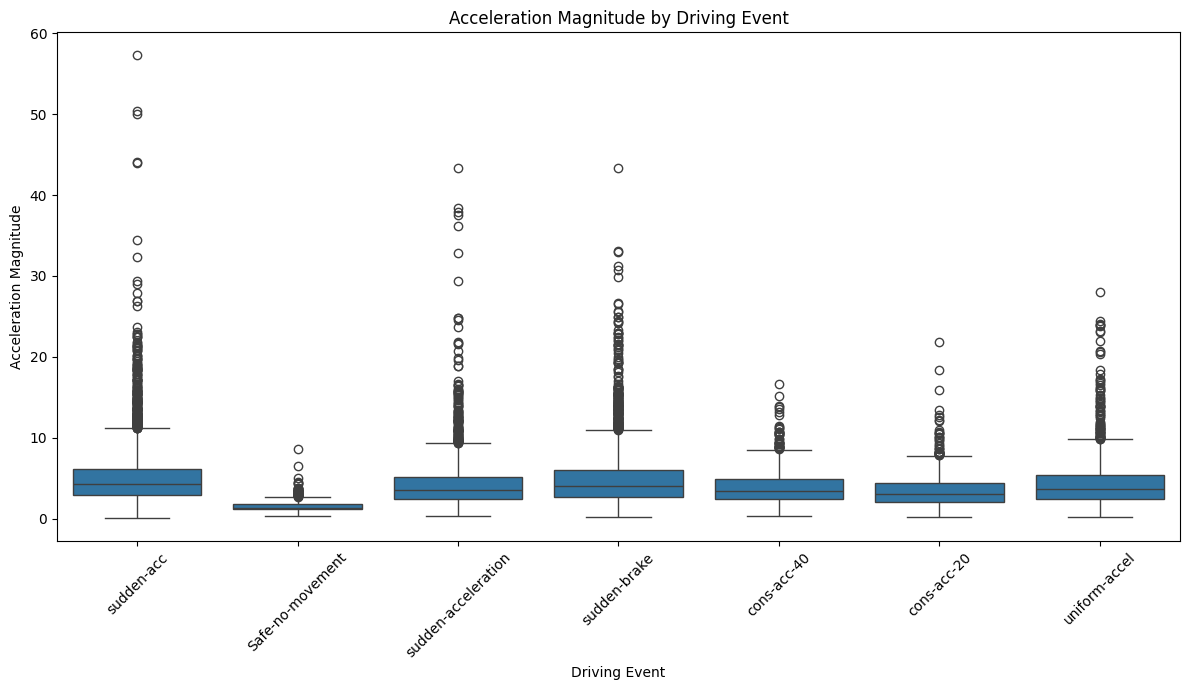

In [23]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='harsh_event',
    y='acc_magnitude'
)

plt.title('Acceleration Magnitude by Driving Event')
plt.xlabel('Driving Event')
plt.ylabel('Acceleration Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

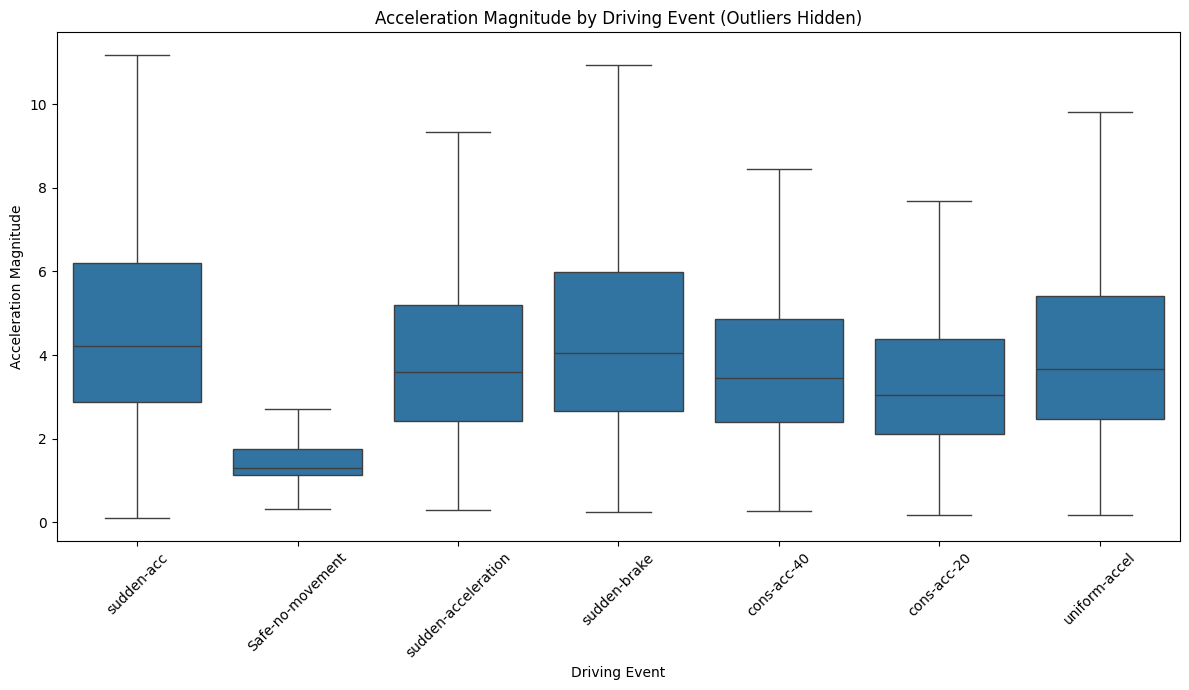

In [24]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='harsh_event',
    y='acc_magnitude',
    showfliers=False
)

plt.title('Acceleration Magnitude by Driving Event (Outliers Hidden)')
plt.xlabel('Driving Event')
plt.ylabel('Acceleration Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Boxplot with outliers hidden

This is particularly useful because it makes the normal range of each driving event easier to compare without the extreme values dominating the visualization.

Feature Engineering

In [25]:
# Work on the feature-engineered copy
df_features = df.copy()

# Make sure rows are in their original file order
df_features['_row_order'] = df_features.groupby('source_file').cumcount()

# Absolute acceleration components
df_features['acc_x_abs'] = df_features['acc_x'].abs()
df_features['acc_y_abs'] = df_features['acc_y'].abs()
df_features['acc_z_abs'] = df_features['acc_z'].abs()

# Overall acceleration magnitude
df_features['acc_magnitude'] = np.sqrt(
    df_features['acc_x']**2 +
    df_features['acc_y']**2 +
    df_features['acc_z']**2
)

# Horizontal and vertical acceleration
df_features['horizontal_acc'] = np.sqrt(
    df_features['acc_x']**2 +
    df_features['acc_y']**2
)
df_features['vertical_acc'] = df_features['acc_z'].abs()

# Calculate temporal features separately for each CSV/session
group = df_features.groupby('source_file')['acc_magnitude']

df_features['acc_change'] = group.diff()
df_features['acc_change_abs'] = df_features['acc_change'].abs()

df_features['acc_mean_5'] = (
    group.transform(lambda x: x.rolling(5, min_periods=1).mean())
)

df_features['acc_std_5'] = (
    group.transform(lambda x: x.rolling(5, min_periods=1).std())
)

# First observation of each session has no previous value.
# Replace only those generated NaNs with zero.
df_features['acc_change'] = df_features['acc_change'].fillna(0)
df_features['acc_change_abs'] = df_features['acc_change_abs'].fillna(0)
df_features['acc_std_5'] = df_features['acc_std_5'].fillna(0)

# Acceleration intensity
def acceleration_level(x):
    if x < 2:
        return 'Low'
    elif x < 5:
        return 'Moderate'
    elif x < 10:
        return 'High'
    else:
        return 'Extreme'

df_features['acceleration_level'] = (
    df_features['acc_magnitude'].apply(acceleration_level)
)

# Aggressive driving
df_features['aggressive_driving'] = (
    df_features['event_class'] == 1
).astype(int)

# Harsh braking
df_features['is_harsh_braking'] = (
    df_features['harsh_event'] == 'sudden-brake'
).astype(int)

# Rapid acceleration
df_features['is_rapid_acceleration'] = (
    df_features['harsh_event'].isin([
        'sudden-acc',
        'sudden-acceleration'
    ])
).astype(int)

# Smooth acceleration
df_features['is_smooth_acceleration'] = (
    df_features['harsh_event'].isin([
        'uniform-accel',
        'cons-acc-20',
        'cons-acc-40'
    ])
).astype(int)

df_features = df_features.drop(columns=['_row_order'])
print("Feature engineering completed.")


Feature engineering completed.


In [26]:
feature_columns = [
    'acc_x',
    'acc_y',
    'acc_z',
    'acc_magnitude',
    'horizontal_acc',
    'vertical_acc',
    'acc_x_abs',
    'acc_y_abs',
    'acc_z_abs',
    'acc_mean_5',
    'acc_std_5',
    'acc_change',
    'acc_change_abs',
    'acceleration_level',
    'aggressive_driving',
    'is_harsh_braking',
    'is_rapid_acceleration',
    'is_smooth_acceleration'
]

df_features[feature_columns].head()

,acc_x,acc_y,acc_z,acc_magnitude,horizontal_acc,vertical_acc,acc_x_abs,acc_y_abs,acc_z_abs,acc_mean_5,acc_std_5,acc_change,acc_change_abs,acceleration_level,aggressive_driving,is_harsh_braking,is_rapid_acceleration,is_smooth_acceleration
0,1.145268,-1.298755,-4.378979,4.708913,1.731590,4.378979,1.145268,1.298755,4.378979,4.708913,0.000000,0.000000,0.000000,Moderate,0,0,1,0
1,-0.416309,3.788345,-5.346581,6.565881,3.811151,5.346581,0.416309,3.788345,5.346581,5.637397,1.313075,1.856969,1.856969,High,0,0,1,0
2,-0.713296,-1.490359,1.464958,2.208181,1.652259,1.464958,0.713296,1.490359,1.464958,4.494325,2.186761,-4.357701,4.357701,Moderate,0,0,1,0
3,-1.690479,-1.011348,0.018345,1.969995,1.969910,0.018345,1.690479,1.011348,0.018345,3.863243,2.186552,-0.238186,0.238186,Low,0,0,1,0
4,2.793067,-1.557421,3.342682,4.626047,3.197934,3.342682,2.793067,1.557421,3.342682,4.015803,1.924092,2.656051,2.656051,Moderate,0,0,1,0


In [27]:
acc_summary = df.groupby('harsh_event')['acc_magnitude'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(3)

acc_summary

,count,mean,std,min,median,max
harsh_event,,,,,,
Safe-no-movement,483,1.563,0.818,0.323,1.297,8.552
cons-acc-20,822,3.527,2.202,0.169,3.046,21.823
cons-acc-40,1114,3.847,2.109,0.274,3.444,16.673
sudden-acc,5109,5.039,3.555,0.115,4.226,57.259
sudden-acceleration,2997,4.233,3.103,0.303,3.587,43.316
sudden-brake,4698,4.782,3.340,0.253,4.048,43.284
uniform-accel,1648,4.401,3.093,0.185,3.672,28.014


In [28]:
# Threshold obtained from the IQR outlier analysis
aggressive_threshold = 10.32959034570605

# Classify driving behavior
df['driving_style'] = np.where(
    df['acc_magnitude'] > aggressive_threshold,
    'Aggressive',
    'Smooth'
)

# Check the result
df[['acc_magnitude', 'driving_style']].head(10)

,acc_magnitude,driving_style
0,4.708913,Smooth
1,6.565881,Smooth
2,2.208181,Smooth
3,1.969995,Smooth
4,4.626047,Smooth
5,4.288430,Smooth
6,3.437897,Smooth
7,2.115111,Smooth
8,6.579608,Smooth
9,3.133249,Smooth


In [29]:
style_counts = df['driving_style'].value_counts()

print("Driving Style Counts:")
print(style_counts)

print("\nDriving Style Percentages:")
print((style_counts / len(df) * 100).round(2))

Driving Style Counts:
driving_style
Smooth        16122
Aggressive      749
Name: count, dtype: int64

Driving Style Percentages:
driving_style
Smooth        95.56
Aggressive     4.44
Name: count, dtype: float64


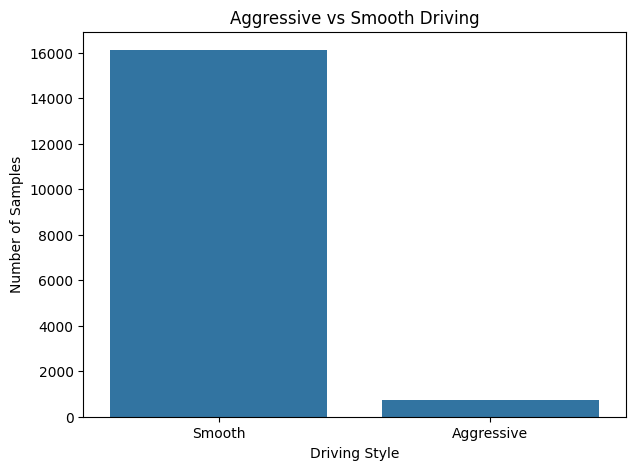

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='driving_style'
)

plt.title('Aggressive vs Smooth Driving')
plt.xlabel('Driving Style')
plt.ylabel('Number of Samples')

plt.show()

In [31]:
style_by_event = pd.crosstab(
    df['harsh_event'],
    df['driving_style']
)

print(style_by_event)

driving_style        Aggressive  Smooth
harsh_event                            
Safe-no-movement              0     483
cons-acc-20                  13     809
cons-acc-40                  18    1096
sudden-acc                  305    4804
sudden-acceleration          97    2900
sudden-brake                250    4448
uniform-accel                66    1582


In [32]:
style_by_event_percent = pd.crosstab(
    df['harsh_event'],
    df['driving_style'],
    normalize='index'
) * 100

print(style_by_event_percent.round(2))

driving_style        Aggressive  Smooth
harsh_event                            
Safe-no-movement           0.00  100.00
cons-acc-20                1.58   98.42
cons-acc-40                1.62   98.38
sudden-acc                 5.97   94.03
sudden-acceleration        3.24   96.76
sudden-brake               5.32   94.68
uniform-accel              4.00   96.00


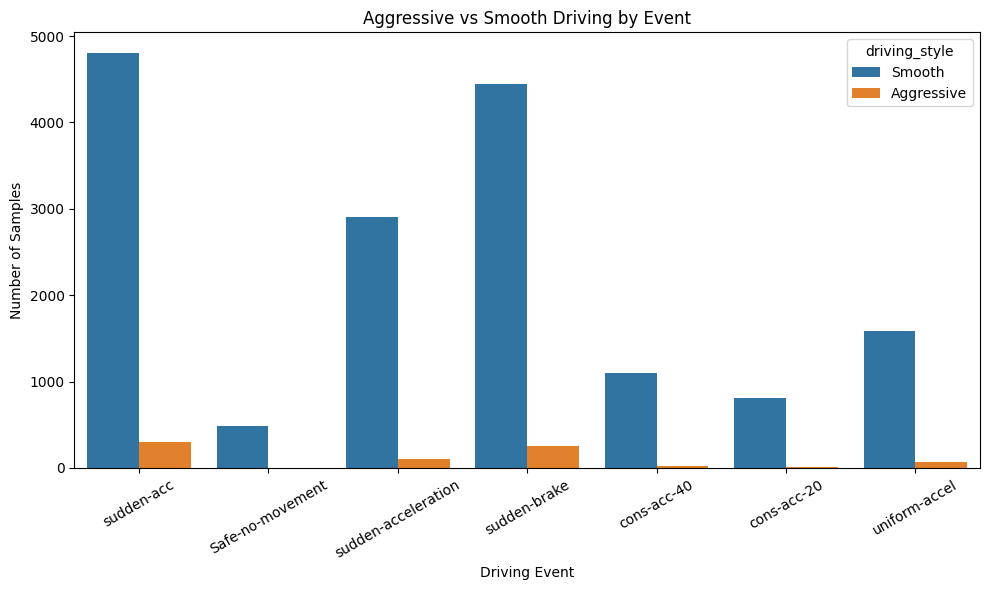

In [33]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='harsh_event',
    hue='driving_style'
)

plt.title('Aggressive vs Smooth Driving by Event')
plt.xlabel('Driving Event')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

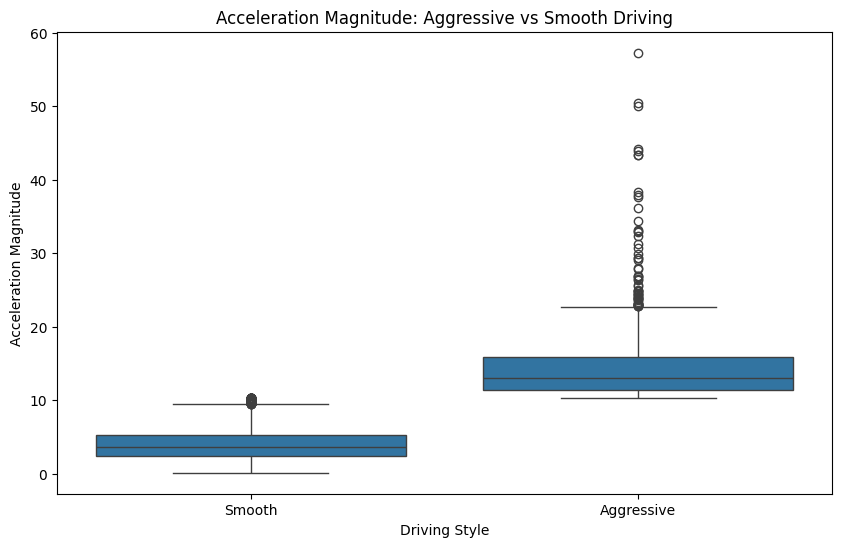

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='driving_style',
    y='acc_magnitude'
)

plt.title('Acceleration Magnitude: Aggressive vs Smooth Driving')
plt.xlabel('Driving Style')
plt.ylabel('Acceleration Magnitude')

plt.show()

In [35]:
style_statistics = df.groupby('driving_style')['acc_magnitude'].agg(
    count='count',
    mean='mean',
    std='std',
    min='min',
    median='median',
    max='max'
)

print(style_statistics.round(3))

               count    mean    std     min  median     max
driving_style                                              
Aggressive       749  14.846  5.566  10.342  13.054  57.259
Smooth         16122   4.030  2.105   0.115   3.647  10.322


In [36]:
aggressive_events = (
    df[df['driving_style'] == 'Aggressive']
    .groupby('harsh_event')
    .size()
    .sort_values(ascending=False)
)

print("Aggressive samples by event:")
print(aggressive_events)

Aggressive samples by event:
harsh_event
sudden-acc             305
sudden-brake           250
sudden-acceleration     97
uniform-accel           66
cons-acc-40             18
cons-acc-20             13
dtype: int64


In [37]:
aggressive_event_percent = (
    df[df['driving_style'] == 'Aggressive']
    .groupby('harsh_event')
    .size()
    / df.groupby('harsh_event').size()
    * 100
)

print("Percentage of aggressive samples within each event:")
print(aggressive_event_percent.round(2).sort_values(ascending=False))

Percentage of aggressive samples within each event:
harsh_event
sudden-acc             5.97
sudden-brake           5.32
uniform-accel          4.00
sudden-acceleration    3.24
cons-acc-40            1.62
cons-acc-20            1.58
Safe-no-movement        NaN
dtype: float64


In [38]:
output_path = '/content/drive/MyDrive/driver_dataset_feature_engineered.csv'

df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/driver_dataset_feature_engineered.csv


Model Training

In [39]:
feature_columns = [
    'acc_x',
    'acc_y',
    'acc_z',
    'acc_magnitude',
    'horizontal_acc',
    'vertical_acc',
    'acc_x_abs',
    'acc_y_abs',
    'acc_z_abs',
    'acc_mean_5',
    'acc_std_5',
    'acc_change',
    'acc_change_abs'
]

# Input features
X = df_features[feature_columns].copy()

# Target
y = df['event_class'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nMissing values:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

X shape: (16871, 13)
y shape: (16871,)

Target distribution:
event_class
0    13175
1     3696
Name: count, dtype: int64

Target percentage:
event_class
0    78.09
1    21.91
Name: proportion, dtype: float64

Missing values:
acc_x             0
acc_y             0
acc_z             0
acc_magnitude     0
horizontal_acc    0
vertical_acc      0
acc_x_abs         0
acc_y_abs         0
acc_z_abs         0
acc_mean_5        0
acc_std_5         0
acc_change        0
acc_change_abs    0
dtype: int64

Total missing values: 0


In [40]:
ml_data = df_features[feature_columns + ['event_class']].dropna().copy()

print("Original dataset:", df.shape)
print("ML dataset after removing missing values:", ml_data.shape)

print("\nMissing values after cleaning:")
print(ml_data[feature_columns].isnull().sum().sum())

Original dataset: (16871, 17)
ML dataset after removing missing values: (16871, 14)

Missing values after cleaning:
0


In [41]:
X = ml_data[feature_columns]
y = ml_data['event_class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16871, 13)
y shape: (16871,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 13496
Testing samples: 3375

Training class distribution:
event_class
0    10539
1     2957
Name: count, dtype: int64

Testing class distribution:
event_class
0    2636
1     739
Name: count, dtype: int64


Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [44]:
# Predictions and probabilities for the held-out test set

y_test_proba = rf_model.predict_proba(X_test)[:, 1]

FINAL_THRESHOLD = 0.15

y_test_final = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

# Keep the default model prediction as well
y_pred = rf_model.predict(X_test)

print("Predictions generated!")
print("First 20 predictions:", y_pred[:20])
print("Final threshold:", FINAL_THRESHOLD)


Predictions generated!
First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Final threshold: 0.15


In [45]:
# ============================================================
# STEP 1 — FIND AND REMOVE DUPLICATE CSV COPIES
# ============================================================

import glob
import os
import hashlib
import pandas as pd

# Find CSVs only in your actual dataset folder
csv_files = glob.glob('/content/driver_dataset/*.csv')

print("CSV files found:", len(csv_files))


# ------------------------------------------------------------
# Check for duplicate files using file content
# ------------------------------------------------------------

file_hashes = {}

for file in csv_files:

    with open(file, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    file_hashes.setdefault(file_hash, []).append(file)


# ------------------------------------------------------------
# Display duplicate groups
# ------------------------------------------------------------

duplicate_groups = [
    files for files in file_hashes.values()
    if len(files) > 1
]

print("Duplicate groups:", len(duplicate_groups))

for i, group in enumerate(duplicate_groups, 1):

    print(f"\nDuplicate group {i}:")

    for file in group:
        print("  ", os.path.basename(file))


# ------------------------------------------------------------
# Keep only ONE copy of each file
# ------------------------------------------------------------

unique_csv_files = [
    files[0]
    for files in file_hashes.values()
]

print("\n==========================================")
print("FINAL FILE COUNT")
print("==========================================")

print("Original CSV count:", len(csv_files))
print("Unique CSV count:", len(unique_csv_files))
print("Duplicate copies removed:",
      len(csv_files) - len(unique_csv_files))

CSV files found: 54
Duplicate groups: 0

FINAL FILE COUNT
Original CSV count: 54
Unique CSV count: 54
Duplicate copies removed: 0


In [46]:
# ============================================================
# STEP 2 — CHECK UNIQUE DRIVING SESSIONS
# ============================================================

session_info = []

for file in unique_csv_files:

    temp = pd.read_csv(file)

    class_counts = temp['event_class'].value_counts()

    session_info.append({
        'filename': os.path.basename(file),
        'rows': len(temp),
        'class_0': class_counts.get(0, 0),
        'class_1': class_counts.get(1, 0)
    })

sessions_df = pd.DataFrame(session_info)

print(sessions_df.to_string(index=False))

print("\n==========================================")
print("TOTAL UNIQUE ROWS")
print("==========================================")

print("Total rows:", sessions_df['rows'].sum())

                                                              filename  rows  class_0  class_1
            paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-1-52.csv   426      204      222
           paved_sudden-acc_const-acc-at-60kmph_22-3-2023_20-35-48.csv   498      320      178
 paved_sudden-left-line-chg_const-acc-at-40kmph_22-3-2023_19-53-57.csv   483      270      213
                paved_safe-no-movement_zero-acc_22-3-2023_19-48-10.csv   483      483        0
    paved_sudden-right-turn_const-acc-at-20kmph_22-3-2023_20-12-12.csv   549      405      144
    paved_sudden-right-turn_const-acc-at-20kmph_22-3-2023_20-17-28.csv   619      483      136
           paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-50-49.csv   865      530      335
          paved_sudden-brake_const-acc-at-60kmph_22-3-2023_20-4-53.csv   760      649      111
         paved_sudden-brake_const-acc-at-20kmph_22-3-2023_19-18-52.csv   300      219       81
 paved_sudden-left-line-chg_const-acc-at-20kmph_20

Total unique CSV files: 54
Total raw rows: 32987

GENUINELY UNSEEN FILE
paved_sudden-right-line-chg_const-acc-at-20kmph_22-3-2023_19-37-54.csv
Rows: 471

Class distribution:
event_class
0    250
1    221
Name: count, dtype: int64

FINAL DATASET SIZES
Training: (32516, 13)
Unseen: (471, 13)

Training class distribution:
event_class
0    23237
1     9279
Name: count, dtype: int64

Unseen class distribution:
event_class
0    250
1    221
Name: count, dtype: int64

Random Forest training completed.

FINAL UNSEEN-DATA PERFORMANCE
Unseen file: paved_sudden-right-line-chg_const-acc-at-20kmph_22-3-2023_19-37-54.csv
Threshold: 0.15

Accuracy  : 0.5011
Precision : 0.4836
Recall    : 0.9321
F1 Score  : 0.6368
ROC-AUC   : 0.6081

Classification Report:
                precision    recall  f1-score   support

Non-Aggressive       0.67      0.12      0.20       250
    Aggressive       0.48      0.93      0.64       221

      accuracy                           0.50       471
     macro avg       0.

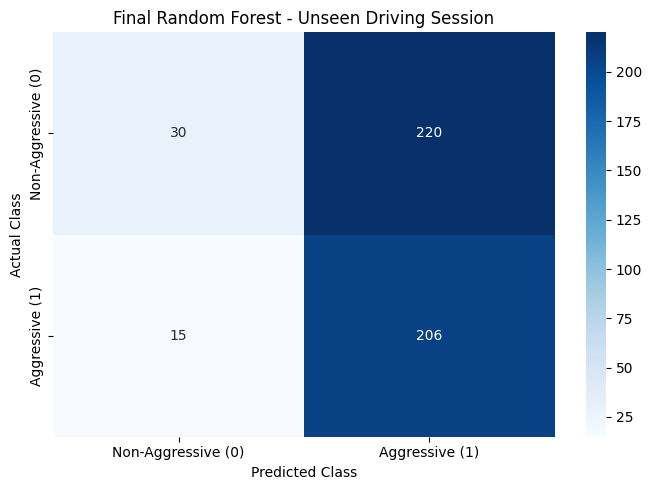

In [47]:
# ============================================================
# FINAL FILE-LEVEL UNSEEN-DATA EXPERIMENT
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Total unique CSV files:", len(unique_csv_files))
print("Total raw rows:", sessions_df['rows'].sum())

# Prefer the final unseen file used in the project.
preferred_unseen_name = (
    'paved_sudden-right-line-chg_const-acc-at-20kmph_22-3-2023_19-37-54.csv'
)

preferred_matches = [
    f for f in unique_csv_files
    if os.path.basename(f) == preferred_unseen_name
]

if preferred_matches:
    UNSEEN_FILE = preferred_matches[0]
else:
    # Fallback: reproducibly select a file containing both classes.
    rng = np.random.RandomState(42)
    candidate_files = []

    for file in unique_csv_files:
        temp = pd.read_csv(file)
        if (
            'event_class' in temp.columns
            and temp['event_class'].nunique() == 2
            and temp['event_class'].value_counts().min() >= 50
        ):
            candidate_files.append(file)

    if not candidate_files:
        raise ValueError("No suitable unseen CSV containing both classes was found.")

    UNSEEN_FILE = rng.choice(candidate_files)

print("\n==========================================")
print("GENUINELY UNSEEN FILE")
print("==========================================")
print(os.path.basename(UNSEEN_FILE))

unseen_original = pd.read_csv(UNSEEN_FILE)

print("Rows:", len(unseen_original))
print("\nClass distribution:")
print(unseen_original['event_class'].value_counts())

feature_columns = [
    'acc_x', 'acc_y', 'acc_z', 'acc_magnitude',
    'horizontal_acc', 'vertical_acc',
    'acc_x_abs', 'acc_y_abs', 'acc_z_abs',
    'acc_mean_5', 'acc_std_5',
    'acc_change', 'acc_change_abs'
]

def create_features(data):
    data = data.copy()

    data['acc_magnitude'] = np.sqrt(
        data['acc_x']**2 + data['acc_y']**2 + data['acc_z']**2
    )
    data['horizontal_acc'] = np.sqrt(
        data['acc_x']**2 + data['acc_y']**2
    )
    data['vertical_acc'] = data['acc_z'].abs()

    data['acc_x_abs'] = data['acc_x'].abs()
    data['acc_y_abs'] = data['acc_y'].abs()
    data['acc_z_abs'] = data['acc_z'].abs()

    data['acc_mean_5'] = (
        data['acc_magnitude'].rolling(5, min_periods=1).mean()
    )
    data['acc_std_5'] = (
        data['acc_magnitude'].rolling(5, min_periods=1).std()
    )

    data['acc_change'] = data['acc_magnitude'].diff()
    data['acc_change_abs'] = data['acc_change'].abs()

    # Match the main feature-engineering treatment of first-row/session NaNs.
    data['acc_change'] = data['acc_change'].fillna(0)
    data['acc_change_abs'] = data['acc_change_abs'].fillna(0)
    data['acc_std_5'] = data['acc_std_5'].fillna(0)

    return data

train_files = [f for f in unique_csv_files if f != UNSEEN_FILE]

train_parts = []
for file in train_files:
    temp = create_features(pd.read_csv(file))
    temp = temp[feature_columns + ['event_class']].dropna(
        subset=feature_columns + ['event_class']
    )
    train_parts.append(temp)

train_df_final = pd.concat(train_parts, ignore_index=True)

unseen_df_final = create_features(unseen_original)
unseen_df_final = unseen_df_final[
    feature_columns + ['event_class']
].dropna(subset=feature_columns + ['event_class'])

X_train_final = train_df_final[feature_columns]
y_train_final = train_df_final['event_class']
X_unseen_final = unseen_df_final[feature_columns]
y_unseen_final = unseen_df_final['event_class']

print("\n==========================================")
print("FINAL DATASET SIZES")
print("==========================================")
print("Training:", X_train_final.shape)
print("Unseen:", X_unseen_final.shape)
print("\nTraining class distribution:")
print(y_train_final.value_counts())
print("\nUnseen class distribution:")
print(y_unseen_final.value_counts())

final_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

final_rf.fit(X_train_final, y_train_final)

print("\nRandom Forest training completed.")

unseen_probabilities = final_rf.predict_proba(X_unseen_final)[:, 1]

# Use the same project operating threshold.
THRESHOLD = FINAL_THRESHOLD

unseen_predictions = (
    unseen_probabilities >= THRESHOLD
).astype(int)

accuracy = accuracy_score(y_unseen_final, unseen_predictions)
precision = precision_score(y_unseen_final, unseen_predictions, zero_division=0)
recall = recall_score(y_unseen_final, unseen_predictions, zero_division=0)
f1 = f1_score(y_unseen_final, unseen_predictions, zero_division=0)
roc_auc = roc_auc_score(y_unseen_final, unseen_probabilities)

print("\n==========================================")
print("FINAL UNSEEN-DATA PERFORMANCE")
print("==========================================")
print("Unseen file:", os.path.basename(UNSEEN_FILE))
print("Threshold:", THRESHOLD)
print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_unseen_final,
    unseen_predictions,
    target_names=['Non-Aggressive', 'Aggressive'],
    zero_division=0
))

cm = confusion_matrix(y_unseen_final, unseen_predictions)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Aggressive (0)', 'Aggressive (1)'],
    yticklabels=['Non-Aggressive (0)', 'Aggressive (1)']
)
plt.title('Final Random Forest - Unseen Driving Session')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

# Compatibility aliases used by later cells.
# unseen_df keeps the complete unseen feature dataframe for representative predictions.
unseen_df = create_features(unseen_original)


FINAL FEATURE IMPORTANCE
           Feature  Importance
0       acc_mean_5    0.129316
1        acc_std_5    0.086296
2   horizontal_acc    0.080900
3    acc_magnitude    0.076366
4        acc_y_abs    0.075734
5            acc_y    0.074542
6        acc_x_abs    0.072435
7   acc_change_abs    0.071017
8            acc_x    0.071007
9       acc_change    0.070963
10           acc_z    0.067157
11       acc_z_abs    0.062345
12    vertical_acc    0.061921


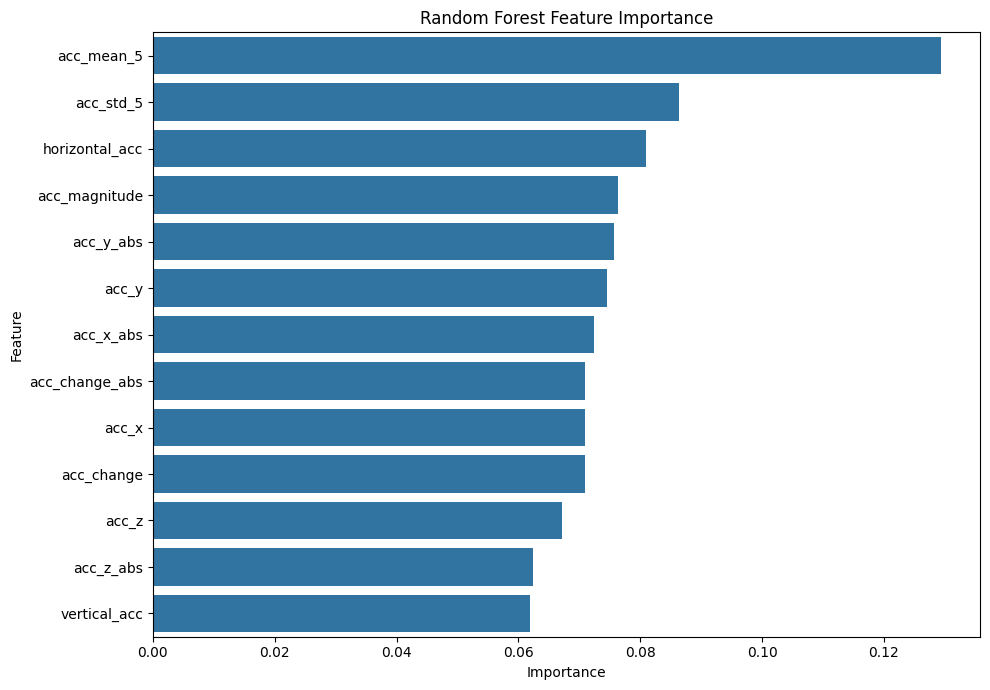

In [48]:
# ============================================================
# FINAL MODEL — FEATURE IMPORTANCE ANALYSIS
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)

print("==========================================")
print("FINAL FEATURE IMPORTANCE")
print("==========================================")
print(feature_importance)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


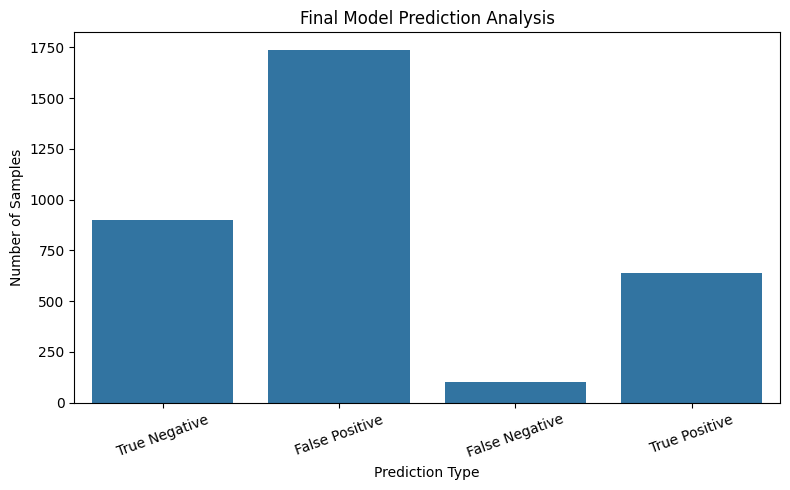

Error summary:
prediction_type
True Positive      637
False Positive    1737
True Negative      899
False Negative     102
Name: count, dtype: int64


In [49]:
# ============================================================
# ERROR ANALYSIS VISUALIZATION
# ============================================================

error_analysis = X_test.copy()
error_analysis['actual'] = y_test.values
error_analysis['predicted'] = y_test_final

def prediction_type(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'True Positive'
    if row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive'
    if row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative'
    return 'False Negative'

error_analysis['prediction_type'] = error_analysis.apply(
    prediction_type,
    axis=1
)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=error_analysis,
    x='prediction_type',
    order=[
        'True Negative',
        'False Positive',
        'False Negative',
        'True Positive'
    ]
)
plt.title('Final Model Prediction Analysis')
plt.xlabel('Prediction Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Error summary:")
print(
    error_analysis['prediction_type']
    .value_counts()
    .reindex([
        'True Positive',
        'False Positive',
        'True Negative',
        'False Negative'
    ])
)


In [50]:
# ==========================================
# FINAL MODEL EVALUATION SETUP
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Final operating threshold
FINAL_THRESHOLD = 0.15

y_final_pred = (y_test_proba >= FINAL_THRESHOLD).astype(int)

final_accuracy = accuracy_score(y_test, y_final_pred)
final_precision = precision_score(y_test, y_final_pred, zero_division=0)
final_recall = recall_score(y_test, y_final_pred, zero_division=0)
final_f1 = f1_score(y_test, y_final_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_test_proba)
final_pr_auc = average_precision_score(y_test, y_test_proba)

print("=" * 60)
print("FINAL RANDOM FOREST EVALUATION")
print("=" * 60)

print(f"Threshold : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_final_pred,
    target_names=['Non-Aggressive', 'Aggressive'],
    digits=4
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_final_pred))

FINAL RANDOM FOREST EVALUATION
Threshold : 0.15
Accuracy  : 0.4551
Precision : 0.2683
Recall    : 0.8620
F1 Score  : 0.4093
ROC-AUC   : 0.6475
PR-AUC    : 0.3230

Classification Report:
                precision    recall  f1-score   support

Non-Aggressive     0.8981    0.3410    0.4944      2636
    Aggressive     0.2683    0.8620    0.4093       739

      accuracy                         0.4551      3375
     macro avg     0.5832    0.6015    0.4518      3375
  weighted avg     0.7602    0.4551    0.4757      3375


Confusion Matrix:
[[ 899 1737]
 [ 102  637]]


In [51]:
# ==========================================
# FINAL PERFORMANCE METRICS
# ==========================================

final_accuracy = accuracy_score(y_test, y_test_final)
final_precision = precision_score(y_test, y_test_final, zero_division=0)
final_recall = recall_score(y_test, y_test_final, zero_division=0)
final_f1 = f1_score(y_test, y_test_final, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_test_proba)
final_pr_auc = average_precision_score(y_test, y_test_proba)

print("=" * 50)
print("FINAL RANDOM FOREST PERFORMANCE")
print("=" * 50)

print(f"Threshold : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")


FINAL RANDOM FOREST PERFORMANCE
Threshold : 0.15
Accuracy  : 0.4551
Precision : 0.2683
Recall    : 0.8620
F1 Score  : 0.4093
ROC-AUC   : 0.6475
PR-AUC    : 0.3230


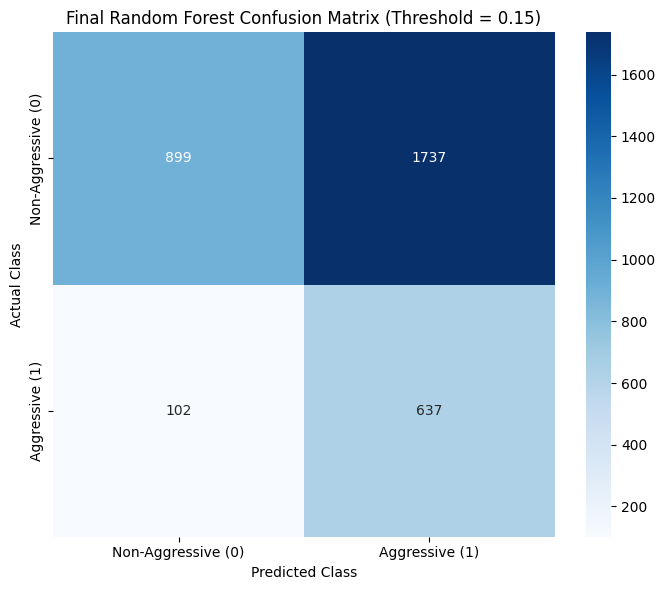

In [52]:
cm = confusion_matrix(y_test, y_final_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Aggressive (0)', 'Aggressive (1)'],
    yticklabels=['Non-Aggressive (0)', 'Aggressive (1)']
)

plt.title('Final Random Forest Confusion Matrix (Threshold = 0.15)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

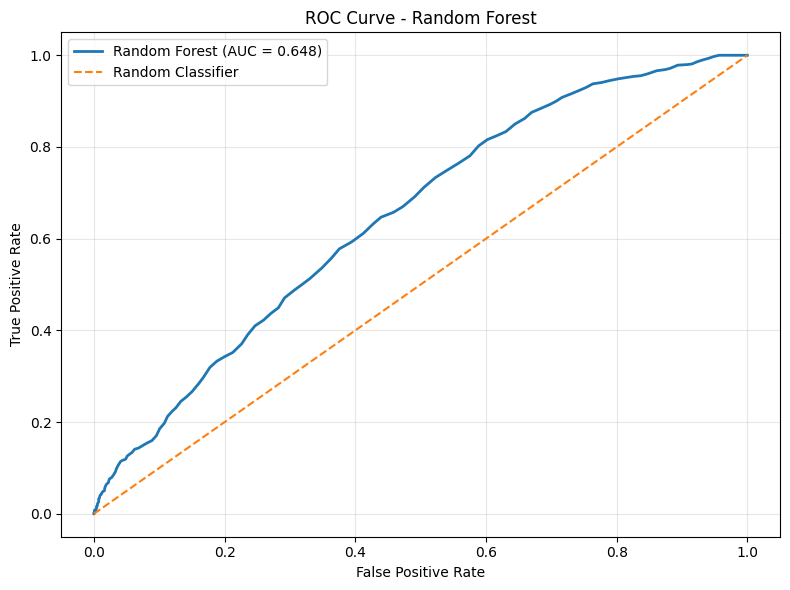

In [53]:
# ==========================================
# ROC CURVE
# ==========================================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {final_roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

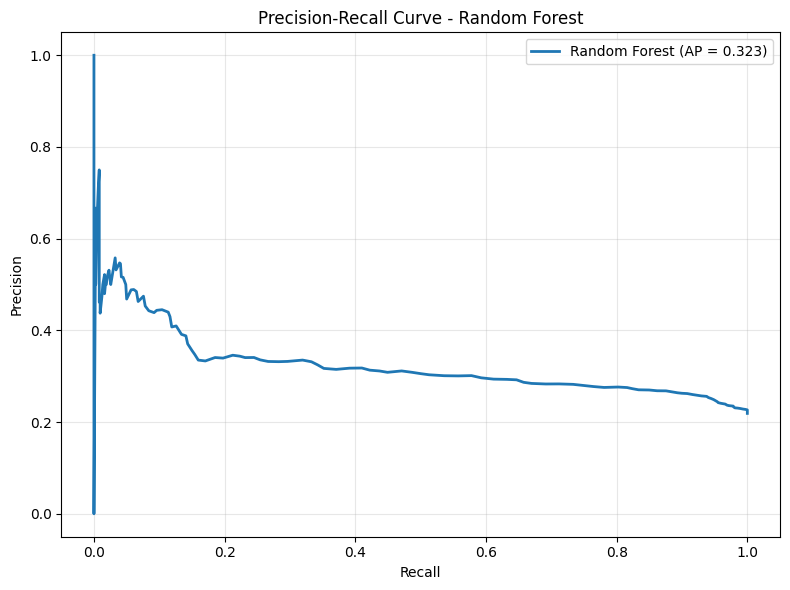

In [54]:
# ==========================================
# PRECISION-RECALL CURVE
# ==========================================

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

pr_auc = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f'Random Forest (AP = {pr_auc:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

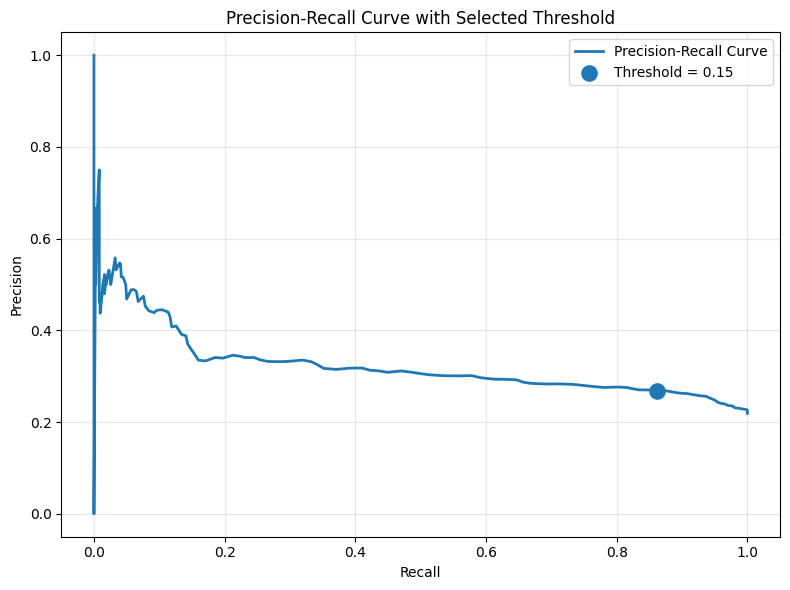

Selected threshold : 0.15
Precision          : 0.2683
Recall             : 0.8620


In [55]:
# ==========================================
# SELECTED THRESHOLD ON PR CURVE
# ==========================================

selected_precision = precision_score(
    y_test,
    y_test_final,
    zero_division=0
)

selected_recall = recall_score(
    y_test,
    y_test_final,
    zero_division=0
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label='Precision-Recall Curve'
)

plt.scatter(
    selected_recall,
    selected_precision,
    s=120,
    label=f'Threshold = {FINAL_THRESHOLD}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Selected Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Selected threshold : {FINAL_THRESHOLD}")
print(f"Precision          : {selected_precision:.4f}")
print(f"Recall             : {selected_recall:.4f}")

In [56]:
# ==========================================
# THRESHOLD ANALYSIS
# ==========================================

thresholds = np.arange(0.10, 0.56, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (y_test_proba >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.3804,0.2535,0.9405,0.3993
1,0.15,0.4640,0.2700,0.8498,0.4098
2,0.20,0.5490,0.2831,0.6915,0.4017
3,0.25,0.6353,0.3032,0.5129,0.3811
4,0.30,0.6921,0.3171,0.3518,0.3335
5,0.35,0.7366,0.3438,0.2233,0.2707
6,0.40,0.7647,0.3913,0.1340,0.1996
7,0.45,0.7775,0.4531,0.0785,0.1338
8,0.50,0.7825,0.5455,0.0406,0.0756
9,0.55,0.7810,0.5000,0.0176,0.0340


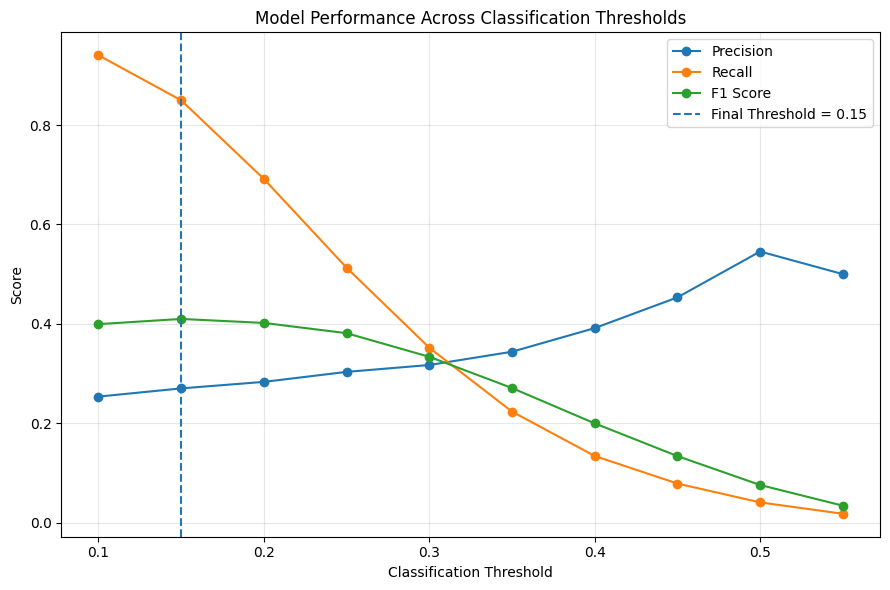

In [57]:
# ==========================================
# THRESHOLD PERFORMANCE PLOT
# ==========================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='o',
    label='F1 Score'
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle='--',
    label=f'Final Threshold = {FINAL_THRESHOLD}'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Model Performance Across Classification Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# ==========================================
# FINAL CLASSIFICATION REPORT
# ==========================================

print("=" * 60)
print("FINAL CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_test_final,
        target_names=[
            'Non-Aggressive',
            'Aggressive'
        ],
        digits=4
    )
)

FINAL CLASSIFICATION REPORT
                precision    recall  f1-score   support

Non-Aggressive     0.8981    0.3410    0.4944      2636
    Aggressive     0.2683    0.8620    0.4093       739

      accuracy                         0.4551      3375
     macro avg     0.5832    0.6015    0.4518      3375
  weighted avg     0.7602    0.4551    0.4757      3375



In [59]:
# ==========================================
# FINAL FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.round(4))

,Feature,Importance
0,acc_mean_5,0.1293
1,acc_std_5,0.0863
2,horizontal_acc,0.0809
3,acc_magnitude,0.0764
4,acc_y_abs,0.0757
5,acc_y,0.0745
6,acc_x_abs,0.0724
7,acc_change_abs,0.0710
8,acc_x,0.0710
9,acc_change,0.0710


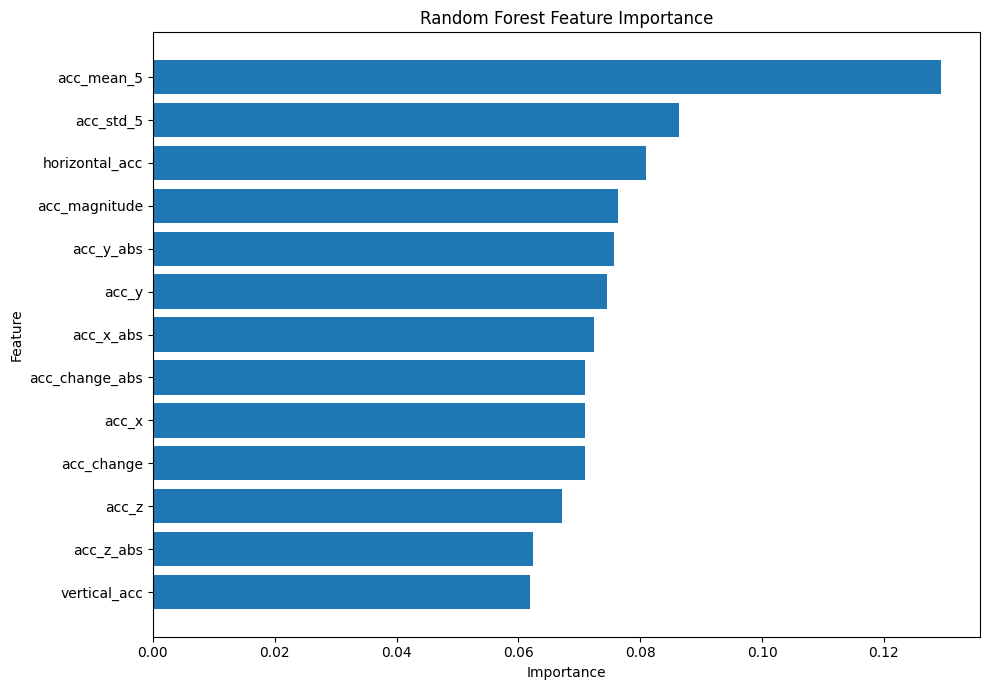

In [60]:
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [61]:
# ==========================================
# FINAL EVALUATION SUMMARY
# ==========================================

final_summary = pd.DataFrame({
    'Metric': [
        'Classification Threshold',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        'PR-AUC',
        'Test Samples'
    ],
    'Value': [
        FINAL_THRESHOLD,
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc,
        len(y_test)
    ]
})

display(final_summary.round(4))

,Metric,Value
0,Classification Threshold,0.1500
1,Accuracy,0.4551
2,Precision,0.2683
3,Recall,0.8620
4,F1 Score,0.4093
5,ROC-AUC,0.6475
6,PR-AUC,0.3230
7,Test Samples,3375.0000


In [62]:
# ==========================================
# DRIVER SAFETY SCORE - SETUP
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use the feature-engineered dataset already created above.
# This avoids depending on a separate file named
# 'cleaned_acceleration_braking_dataset.csv'.
df = df_features.copy()

print("Dataset shape:", df.shape)
print("\nUnique source files:", df['source_file'].nunique())
print("\nRequired columns available:")
print([
    c for c in [
        'source_file', 'event_class', 'acc_magnitude',
        'harsh_event'
    ] if c in df.columns
])


Dataset shape: (16871, 30)

Unique source files: 26

Required columns available:
['source_file', 'event_class', 'acc_magnitude', 'harsh_event']


In [63]:
# ==========================================
# CREATE / VERIFY REQUIRED FEATURES
# ==========================================

# Acceleration magnitude
if 'acc_magnitude' not in df.columns:
    df['acc_magnitude'] = np.sqrt(
        df['acc_x']**2 +
        df['acc_y']**2 +
        df['acc_z']**2
    )

# Absolute acceleration components
df['acc_x_abs'] = df['acc_x'].abs()
df['acc_y_abs'] = df['acc_y'].abs()
df['acc_z_abs'] = df['acc_z'].abs()

# Horizontal and vertical acceleration
df['horizontal_acc'] = np.sqrt(
    df['acc_x']**2 +
    df['acc_y']**2
)

df['vertical_acc'] = df['acc_z'].abs()

# Rolling acceleration statistics
df['acc_mean_5'] = (
    df.groupby('source_file')['acc_magnitude']
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

df['acc_std_5'] = (
    df.groupby('source_file')['acc_magnitude']
      .transform(lambda x: x.rolling(5, min_periods=1).std())
)

# Acceleration change
df['acc_change'] = (
    df.groupby('source_file')['acc_magnitude']
      .diff()
)

df['acc_change_abs'] = df['acc_change'].abs()

# Fill the first-row NaN generated by diff()
df['acc_change'] = df['acc_change'].fillna(0)
df['acc_change_abs'] = df['acc_change_abs'].fillna(0)
df['acc_std_5'] = df['acc_std_5'].fillna(0)

print("Required features created.")

Required features created.


In [64]:
# ==========================================
# BEHAVIOURAL INDICATORS
# ==========================================

# Aggressive event indicator
df['aggressive_event'] = (df['event_class'] == 1).astype(int)

# ------------------------------------------
# Harsh braking
# ------------------------------------------

# Existing feature?
if 'is_harsh_braking' not in df.columns:

    braking_events = [
        'sudden-brake'
    ]

    df['is_harsh_braking'] = (
        df['harsh_event']
        .isin(braking_events)
        .astype(int)
    )


# ------------------------------------------
# Rapid acceleration
# ------------------------------------------

if 'is_rapid_acceleration' not in df.columns:

    acceleration_events = [
        'sudden-acc',
        'sudden-acceleration'
    ]

    df['is_rapid_acceleration'] = (
        df['harsh_event']
        .isin(acceleration_events)
        .astype(int)
    )


# ------------------------------------------
# Smooth acceleration
# ------------------------------------------

if 'is_smooth_acceleration' not in df.columns:

    # Smooth acceleration = relatively low
    # short-term acceleration variation
    smooth_threshold = df['acc_std_5'].quantile(0.50)

    df['is_smooth_acceleration'] = (
        (df['acc_std_5'] <= smooth_threshold) &
        (df['is_rapid_acceleration'] == 0) &
        (df['is_harsh_braking'] == 0)
    ).astype(int)


print("\nIndicator counts:")
print("Aggressive events :", df['aggressive_event'].sum())
print("Harsh braking     :", df['is_harsh_braking'].sum())
print("Rapid acceleration:", df['is_rapid_acceleration'].sum())
print("Smooth acceleration:", df['is_smooth_acceleration'].sum())


Indicator counts:
Aggressive events : 3696
Harsh braking     : 4698
Rapid acceleration: 8106
Smooth acceleration: 3584


In [65]:
# ==========================================
# RANDOM FOREST PREDICTIONS
# ==========================================

FINAL_THRESHOLD = 0.15

feature_columns = [
    'acc_x', 'acc_y', 'acc_z',
    'acc_magnitude', 'horizontal_acc', 'vertical_acc',
    'acc_x_abs', 'acc_y_abs', 'acc_z_abs',
    'acc_mean_5', 'acc_std_5',
    'acc_change', 'acc_change_abs'
]

missing_features = [c for c in feature_columns if c not in df.columns]

if missing_features:
    raise ValueError(f"Missing features: {missing_features}")

ml_df = df.dropna(subset=feature_columns).copy()

ml_df['aggressive_probability'] = (
    rf_model.predict_proba(ml_df[feature_columns])[:, 1]
)

ml_df['model_aggressive'] = (
    ml_df['aggressive_probability'] >= FINAL_THRESHOLD
).astype(int)

print("Predictions generated.")
print("Rows used:", len(ml_df))


Predictions generated.
Rows used: 16871


In [66]:
# ==========================================
# TRIP-LEVEL BEHAVIOURAL INDICATORS
# ==========================================

trip_summary = (
    ml_df
    .groupby('source_file')
    .agg(
        total_samples=('event_class', 'size'),

        # Ground-truth aggressive rate
        aggressive_event_rate=('aggressive_event', 'mean'),

        # Model-predicted aggressive rate
        predicted_aggressive_rate=('model_aggressive', 'mean'),

        # Average model confidence
        mean_aggressive_probability=(
            'aggressive_probability',
            'mean'
        ),

        # Harsh braking
        harsh_braking_rate=(
            'is_harsh_braking',
            'mean'
        ),

        # Rapid acceleration
        rapid_acceleration_rate=(
            'is_rapid_acceleration',
            'mean'
        ),

        # Smooth driving
        smooth_acceleration_rate=(
            'is_smooth_acceleration',
            'mean'
        ),

        # Acceleration behaviour
        mean_acceleration=(
            'acc_magnitude',
            'mean'
        ),

        median_acceleration=(
            'acc_magnitude',
            'median'
        ),

        acceleration_variability=(
            'acc_std_5',
            'mean'
        ),

        mean_acc_change=(
            'acc_change_abs',
            'mean'
        )
    )
    .reset_index()
)

print("Trip-level dataset:")
display(trip_summary.head())

print("\nNumber of trips:", len(trip_summary))

Trip-level dataset:


,source_file,total_samples,aggressive_event_rate,predicted_aggressive_rate,mean_aggressive_probability,harsh_braking_rate,rapid_acceleration_rate,smooth_acceleration_rate,mean_acceleration,median_acceleration,acceleration_variability,mean_acc_change
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,944,0.0,0.325212,0.151928,0.0,1.0,0.0,6.891317,6.086389,2.897689,3.338393
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,1648,0.0,0.197816,0.104927,0.0,0.0,1.0,4.400601,3.672059,2.010152,2.364898
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,483,0.0,0.002070,0.009845,0.0,0.0,0.0,1.563313,1.297141,0.454516,0.480388
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,822,0.0,0.115572,0.078145,0.0,0.0,1.0,3.527300,3.046245,1.734392,2.083241
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,1114,0.0,0.171454,0.098057,0.0,0.0,1.0,3.847173,3.444110,1.758263,2.094733



Number of trips: 26


In [67]:
# ==========================================
# CONVERT RATES TO PERCENTAGES
# ==========================================

rate_columns = [
    'aggressive_event_rate',
    'predicted_aggressive_rate',
    'harsh_braking_rate',
    'rapid_acceleration_rate',
    'smooth_acceleration_rate'
]

for col in rate_columns:
    trip_summary[col + '_pct'] = (
        trip_summary[col] * 100
    )

display(
    trip_summary[
        [
            'source_file',
            'total_samples',
            'aggressive_event_rate_pct',
            'predicted_aggressive_rate_pct',
            'harsh_braking_rate_pct',
            'rapid_acceleration_rate_pct',
            'smooth_acceleration_rate_pct'
        ]
    ].head(10).round(2)
)

,source_file,total_samples,aggressive_event_rate_pct,predicted_aggressive_rate_pct,harsh_braking_rate_pct,rapid_acceleration_rate_pct,smooth_acceleration_rate_pct
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,944,0.00,32.52,0.0,100.0,0.0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,1648,0.00,19.78,0.0,0.0,100.0
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,483,0.00,0.21,0.0,0.0,0.0
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,822,0.00,11.56,0.0,0.0,100.0
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,1114,0.00,17.15,0.0,0.0,100.0
5,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,865,38.73,41.50,0.0,100.0,0.0
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,1236,37.38,48.46,0.0,100.0,0.0
7,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,500,44.60,51.40,0.0,100.0,0.0
8,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,396,22.98,34.34,0.0,100.0,0.0
9,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,625,33.76,35.52,0.0,100.0,0.0


In [68]:
# ==========================================
# NORMALIZE RISK INDICATORS
# ==========================================

def percentile_risk(series):
    """
    Converts a value into a 0-100 percentile risk.
    Higher value = higher risk.
    """
    return series.rank(pct=True) * 100


trip_summary['aggressive_risk'] = percentile_risk(
    trip_summary['predicted_aggressive_rate']
)

trip_summary['braking_risk'] = percentile_risk(
    trip_summary['harsh_braking_rate']
)

trip_summary['rapid_accel_risk'] = percentile_risk(
    trip_summary['rapid_acceleration_rate']
)

trip_summary['variability_risk'] = percentile_risk(
    trip_summary['acceleration_variability']
)

trip_summary['acc_change_risk'] = percentile_risk(
    trip_summary['mean_acc_change']
)

# Smoothness works in the opposite direction:
# more smooth driving = lower risk
trip_summary['smoothness_risk'] = (
    100 -
    percentile_risk(
        trip_summary['smooth_acceleration_rate']
    )
)

display(
    trip_summary[
        [
            'source_file',
            'aggressive_risk',
            'braking_risk',
            'rapid_accel_risk',
            'variability_risk',
            'acc_change_risk',
            'smoothness_risk'
        ]
    ].head().round(2)
)

,source_file,aggressive_risk,braking_risk,rapid_accel_risk,variability_risk,acc_change_risk,smoothness_risk
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,30.77,36.54,75.0,92.31,92.31,53.85
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,15.38,36.54,25.0,69.23,73.08,3.85
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,3.85,36.54,25.0,3.85,3.85,53.85
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,7.69,36.54,25.0,50.00,50.00,3.85
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,11.54,36.54,25.0,53.85,53.85,3.85


In [69]:
# ==========================================
# DRIVER SAFETY SCORE
# ==========================================

WEIGHTS = {
    'aggressive_risk': 0.30,
    'braking_risk': 0.20,
    'rapid_accel_risk': 0.20,
    'variability_risk': 0.15,
    'acc_change_risk': 0.10,
    'smoothness_risk': 0.05
}

trip_summary['risk_score'] = (
    trip_summary['aggressive_risk'] *
    WEIGHTS['aggressive_risk']

    + trip_summary['braking_risk'] *
    WEIGHTS['braking_risk']

    + trip_summary['rapid_accel_risk'] *
    WEIGHTS['rapid_accel_risk']

    + trip_summary['variability_risk'] *
    WEIGHTS['variability_risk']

    + trip_summary['acc_change_risk'] *
    WEIGHTS['acc_change_risk']

    + trip_summary['smoothness_risk'] *
    WEIGHTS['smoothness_risk']
)

# Convert risk into safety score
trip_summary['safety_score'] = (
    100 - trip_summary['risk_score']
)

# Keep score between 0 and 100
trip_summary['safety_score'] = (
    trip_summary['safety_score']
    .clip(0, 100)
)

print("Safety scores calculated.")

Safety scores calculated.


In [70]:
# ==========================================
# SAFETY SCORE CATEGORIES
# ==========================================

def safety_category(score):

    if score >= 80:
        return 'Safe'

    elif score >= 60:
        return 'Moderate'

    elif score >= 40:
        return 'Risky'

    else:
        return 'High Risk'


trip_summary['risk_level'] = (
    trip_summary['safety_score']
    .apply(safety_category)
)

display(
    trip_summary[
        [
            'source_file',
            'safety_score',
            'risk_level'
        ]
    ]
    .sort_values(
        'safety_score',
        ascending=False
    )
    .round(2)
)

,source_file,safety_score,risk_level
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,82.88,Safe
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,72.69,Moderate
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,70.58,Moderate
21,paved_sudden-brake_const-acc-at-20kmph_22-3-20...,66.15,Moderate
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,65.19,Moderate
22,paved_sudden-brake_const-acc-at-20kmph_22-3-20...,61.15,Moderate
18,paved_sudden-brake_const-acc-at-20kmph_20-2-20...,59.23,Risky
9,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,59.04,Risky
8,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,57.69,Risky
5,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,51.73,Risky


In [71]:
# ==========================================
# FINAL SAFETY SCORE TABLE
# ==========================================

final_safety_table = trip_summary[
    [
        'source_file',
        'total_samples',

        'aggressive_event_rate_pct',
        'predicted_aggressive_rate_pct',

        'harsh_braking_rate_pct',
        'rapid_acceleration_rate_pct',
        'smooth_acceleration_rate_pct',

        'mean_acceleration',
        'acceleration_variability',
        'mean_acc_change',

        'safety_score',
        'risk_level'
    ]
].copy()

final_safety_table = final_safety_table.sort_values(
    'safety_score',
    ascending=True
)

display(
    final_safety_table.round(2)
)

,source_file,total_samples,aggressive_event_rate_pct,predicted_aggressive_rate_pct,harsh_braking_rate_pct,rapid_acceleration_rate_pct,smooth_acceleration_rate_pct,mean_acceleration,acceleration_variability,mean_acc_change,safety_score,risk_level
12,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,307,44.30,60.91,0.0,100.0,0.0,7.51,4.12,4.71,20.00,High Risk
13,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,383,43.08,58.49,0.0,100.0,0.0,6.97,3.11,3.58,23.27,High Risk
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,1236,37.38,48.46,0.0,100.0,0.0,5.05,2.51,2.86,33.08,High Risk
15,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,328,45.43,57.01,0.0,100.0,0.0,4.49,1.89,2.16,34.04,High Risk
19,paved_sudden-brake_const-acc-at-20kmph_20-2-20...,1034,20.41,39.85,100.0,0.0,0.0,5.53,2.70,3.10,35.58,High Risk
16,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,751,36.22,52.20,0.0,100.0,0.0,4.57,1.92,2.28,36.54,High Risk
17,paved_sudden-acc_const-acc-at-60kmph_22-3-2023...,498,35.74,47.39,0.0,100.0,0.0,4.70,2.02,2.32,37.88,High Risk
14,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,332,52.71,56.02,0.0,100.0,0.0,3.94,1.73,2.05,38.08,High Risk
11,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,426,52.11,59.39,0.0,100.0,0.0,4.00,1.64,1.89,38.85,High Risk
25,paved_sudden-brake_const-acc-at-60kmph_22-3-20...,760,14.61,38.42,100.0,0.0,0.0,5.61,2.34,2.76,39.62,High Risk


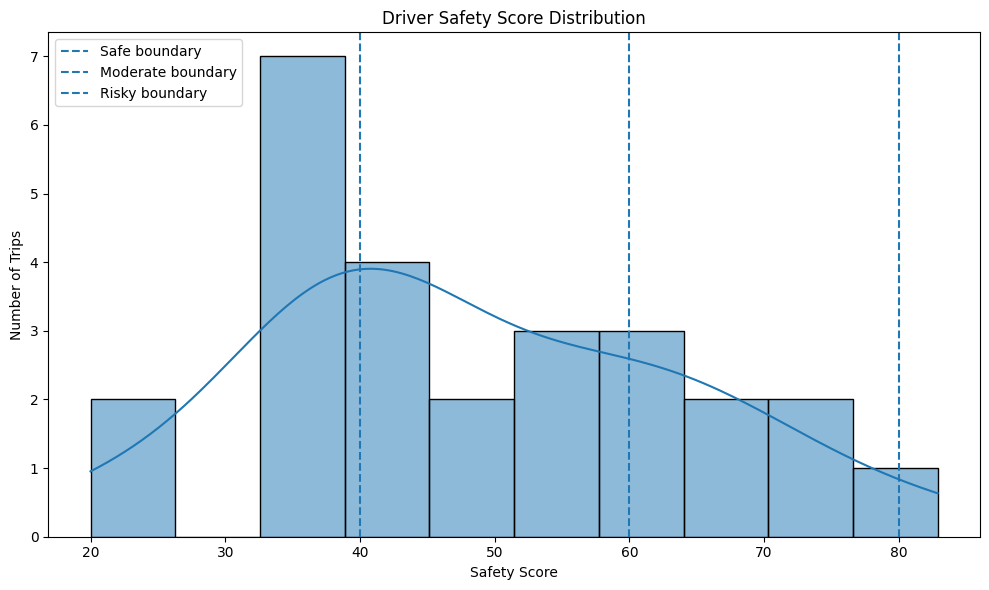

In [72]:
# ==========================================
# SAFETY SCORE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    trip_summary['safety_score'],
    bins=10,
    kde=True
)

plt.axvline(80, linestyle='--', label='Safe boundary')
plt.axvline(60, linestyle='--', label='Moderate boundary')
plt.axvline(40, linestyle='--', label='Risky boundary')

plt.xlabel('Safety Score')
plt.ylabel('Number of Trips')
plt.title('Driver Safety Score Distribution')
plt.legend()

plt.tight_layout()
plt.show()

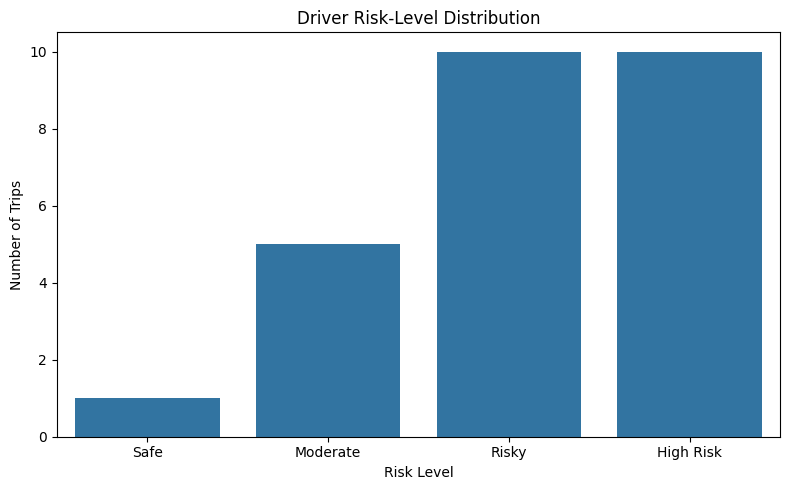

risk_level
Safe          1
Moderate      5
Risky        10
High Risk    10
Name: count, dtype: int64


In [73]:
# ==========================================
# RISK LEVEL DISTRIBUTION
# ==========================================

risk_counts = (
    trip_summary['risk_level']
    .value_counts()
    .reindex(
        ['Safe', 'Moderate', 'Risky', 'High Risk'],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.xlabel('Risk Level')
plt.ylabel('Number of Trips')
plt.title('Driver Risk-Level Distribution')

plt.tight_layout()
plt.show()

print(risk_counts)

In [74]:
# ==========================================
# EXPORT FINAL SAFETY SCORE DATASET
# ==========================================

output_file = "final_driver_safety_scores.csv"

final_safety_table.to_csv(
    output_file,
    index=False
)

print(f"Saved: {output_file}")

Saved: final_driver_safety_scores.csv


In [75]:
from google.colab import files

files.download("final_driver_safety_scores.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
# ==========================================
# REPRESENTATIVE FINAL PREDICTIONS
# ==========================================

unseen_results = unseen_df.copy()

# Remove rows with incomplete model features.
unseen_results = unseen_results.dropna(
    subset=feature_columns
).copy()

X_unseen = unseen_results[feature_columns]

unseen_results['aggressive_probability'] = (
    rf_model.predict_proba(X_unseen)[:, 1]
)

FINAL_THRESHOLD = 0.15

unseen_results['predicted_class'] = (
    unseen_results['aggressive_probability'] >= FINAL_THRESHOLD
).astype(int)

unseen_results['prediction'] = unseen_results['predicted_class'].map({
    0: 'Non-Aggressive',
    1: 'Aggressive'
})

representative_predictions = unseen_results[
    [
        'aggressive_probability',
        'prediction',
        'acc_magnitude',
        'horizontal_acc',
        'vertical_acc',
        'acc_mean_5',
        'acc_std_5',
        'acc_change_abs'
    ]
].sort_values(
    'aggressive_probability',
    ascending=False
)

print("TOP AGGRESSIVE PREDICTIONS")
display(representative_predictions.head(5).round(3))

print("\nTOP NON-AGGRESSIVE PREDICTIONS")
display(
    representative_predictions
    .sort_values('aggressive_probability')
    .head(5)
    .round(3)
)


TOP AGGRESSIVE PREDICTIONS


,aggressive_probability,prediction,acc_magnitude,horizontal_acc,vertical_acc,acc_mean_5,acc_std_5,acc_change_abs
437,0.595,Aggressive,8.336,8.333,0.231,6.670,2.345,0.116
340,0.490,Aggressive,3.895,3.876,0.384,5.401,1.472,2.560
345,0.480,Aggressive,4.395,4.263,1.072,4.621,0.381,0.100
440,0.470,Aggressive,6.903,6.629,1.925,6.141,2.367,3.196
257,0.470,Aggressive,3.952,3.841,0.928,4.096,1.723,2.541



TOP NON-AGGRESSIVE PREDICTIONS


,aggressive_probability,prediction,acc_magnitude,horizontal_acc,vertical_acc,acc_mean_5,acc_std_5,acc_change_abs
35,0.005,Non-Aggressive,1.654,1.466,0.766,1.986,0.738,0.518
33,0.010,Non-Aggressive,2.169,0.710,2.049,2.730,0.829,0.322
9,0.015,Non-Aggressive,3.023,2.007,2.260,2.643,0.993,1.662
34,0.025,Non-Aggressive,1.136,1.118,0.200,2.444,1.101,1.033
120,0.025,Non-Aggressive,1.817,0.824,1.620,2.862,1.084,0.167


In [77]:
# ==========================================
# FINAL PREDICTION SUMMARY
# ==========================================

prediction_summary = pd.DataFrame({
    'Metric': [
        'Total unseen samples',
        'Predicted Non-Aggressive',
        'Predicted Aggressive',
        'Predicted Aggressive %',
        'Mean Aggressive Probability'
    ],
    'Value': [
        len(unseen_results),
        (unseen_results['predicted_class'] == 0).sum(),
        (unseen_results['predicted_class'] == 1).sum(),
        (unseen_results['predicted_class'] == 1).mean() * 100,
        unseen_results['aggressive_probability'].mean()
    ]
})

display(prediction_summary.round(3))

,Metric,Value
0,Total unseen samples,471.000
1,Predicted Non-Aggressive,121.000
2,Predicted Aggressive,350.000
3,Predicted Aggressive %,74.310
4,Mean Aggressive Probability,0.223
